In [20]:
%pwd

'c:\\Users\\TransOrg\\Desktop\\demo-docker\\notebooks'

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import os
os.chdir("..")

In [51]:
import pandas as pd
df = pd.read_csv("data/DataScience_Salaries.csv")
df.sample(3)

,work_year,job_title,job_category,salary,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
545,2025.0,Junior Data Scientist,Data Science,75000.0,Monaco,Entry,Full-time,Remote,Monaco,Small
267,2025.0,Data Mesh Evangelist,Data Architecture,165000.0,United States,Mid,Full-time,Remote,"Austin, TX",Medium
876,2025.0,Junior Data Scientist,Data Science,165000.0,Monaco,Entry,Full-time,Remote,Monaco,Small


In [36]:
from ydata_profiling import ProfileReport
import os
artifacts_dir = os.path.join("artifacts")
os.makedirs(artifacts_dir, exist_ok=True)
report_path = os.path.join(artifacts_dir, "data_profiling_report.html")

profile = ProfileReport(
    df,
    title="Data Profiling Report",
    explorative=True,
    correlations={"pearson": {"calculate": True}, "spearman": {"calculate": True}},  # dict of options
    missing_diagrams={"heatmap": True, "matrix": True}  # expects a dict, not just True
)
profile.to_file(report_path)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 38.87it/s]
c:\Users\TransOrg\Desktop\demo-docker\venv\Lib\site-packages\ydata_profiling\model\correlations.py:87: UserWarning: There was an attempt to calculate the auto correlation, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(correlations={"auto": {"calculate": False}})`
If this is problematic for your use case, please report this as an issue:
https://github.com/ydataai/ydata-profiling/issues
(include the error message: 'putmask: first argument must be an array')
  warnings.warn(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [52]:
df.columns

Index(['work_year', 'job_title', 'job_category', 'salary',
       'employee_residence', 'experience_level', 'employment_type',
       'work_setting', 'company_location', 'company_size'],
      dtype='object')

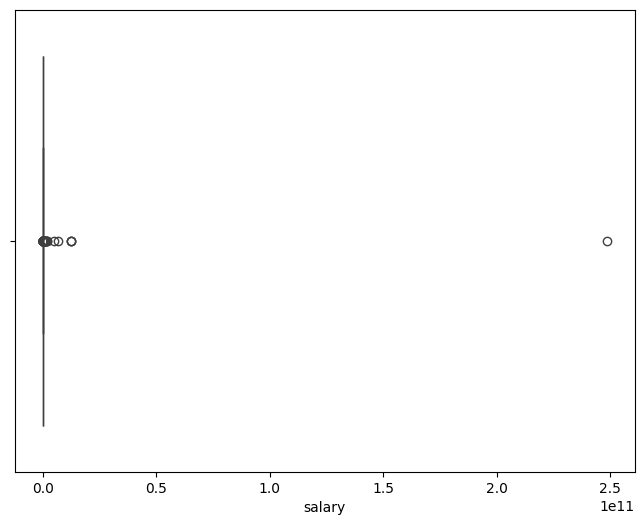

In [46]:
%matplotlib inline
plt.figure(figsize=(8,6))
sns.boxplot(x=df['salary'])
plt.show()

In [57]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_new = df[(df['salary'] >= lower_bound) & (df['salary'] <= upper_bound)]
print("Original size:", df.shape)
print("Cleaned size:", df_new.shape)

Original size: (925, 10)
Cleaned size: (826, 10)


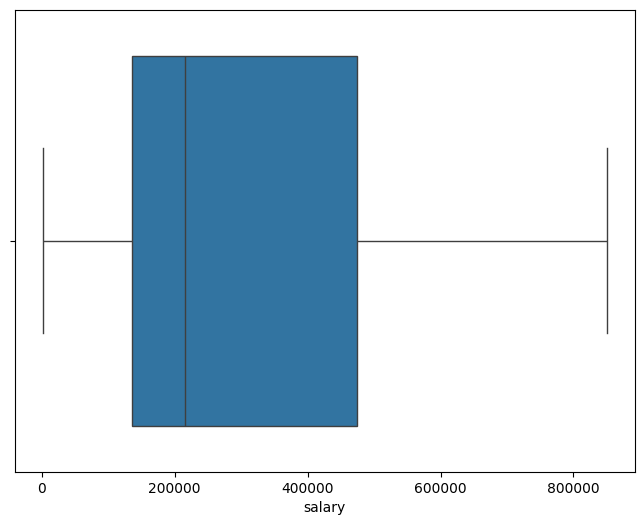

In [58]:
%matplotlib inline
plt.figure(figsize=(8,6))
sns.boxplot(x=df_new['salary'])
plt.show()

In [10]:
from pycaret.regression import *
target = "salary"

reg = setup(
    data=df,
    target=target,
    session_id=42,
    train_size=0.75,
    normalize=True,
    transformation=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    verbose=False
)

In [13]:
best_model = compare_models()
best_model

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,11:23:57
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,66399975.8680,692734385341320192.0000,345127044.5658,-0.0266,1.5011,0.8961,0.0520
par,Passive Aggressive Regressor,66394967.7614,692747698905187584.0000,345163452.9686,-0.0292,1.5816,0.5819,0.0560
knn,K Neighbors Regressor,68643819.9000,692334218740917888.0000,345421204.0000,-0.3383,1.6810,12.0581,0.0560
ada,AdaBoost Regressor,85731921.4834,692677209182957312.0000,351060284.8074,-1.4422,3.7898,96.1922,0.0540
et,Extra Trees Regressor,86127895.9400,688553469520349824.0000,344836669.2418,-3.2155,3.4707,105.2379,0.0750
rf,Random Forest Regressor,98965403.6999,692494393994256256.0000,361283117.1090,-5.7254,3.7587,164.3536,0.1000
gbr,Gradient Boosting Regressor,99551068.1941,692295727280524416.0000,361237015.6107,-5.8245,3.7749,170.0191,0.0630
dt,Decision Tree Regressor,98705488.9429,693140638829303552.0000,362007084.0747,-5.9531,3.7273,165.4567,0.0490
dummy,Dummy Regressor,128077392.8000,694325279366263552.0000,371724993.6000,-11.5226,5.4221,361.6984,0.0410
br,Bayesian Ridge,128077388.3354,694325193650998528.0000,371724989.2086,-11.5226,5.4221,361.6984,0.0470


c:\Users\TransOrg\Desktop\demo-docker\venv\Lib\site-packages\pycaret\internal\pycaret_experiment\supervised_experiment.py:339: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_cols, subset=["TT (Sec)"])


HuberRegressor()

In [14]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [16]:
pred_holdout = predict_model(best_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,1135960082.8137,266470218108359147520.0000,16323915526.2565,-0.0049,1.9751,1.9614


In [19]:
new_data = df.copy().drop('salary',axis=1)
predictions = predict_model(best_model, data = new_data)

In [20]:
save_model(best_model,"best_pipeline")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['work_year'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['job_title', 'job_category',
                                              'employee_residence',
                                              'experience_level',
                                              'employment_type', 'work_setting',
                                              'company_location',
                                              'company_size'],
                                     transformer=SimpleImputer(s...
                                                                     'employee_residence',
                                                                     'company_location'],
                                                               handle_missing='retur